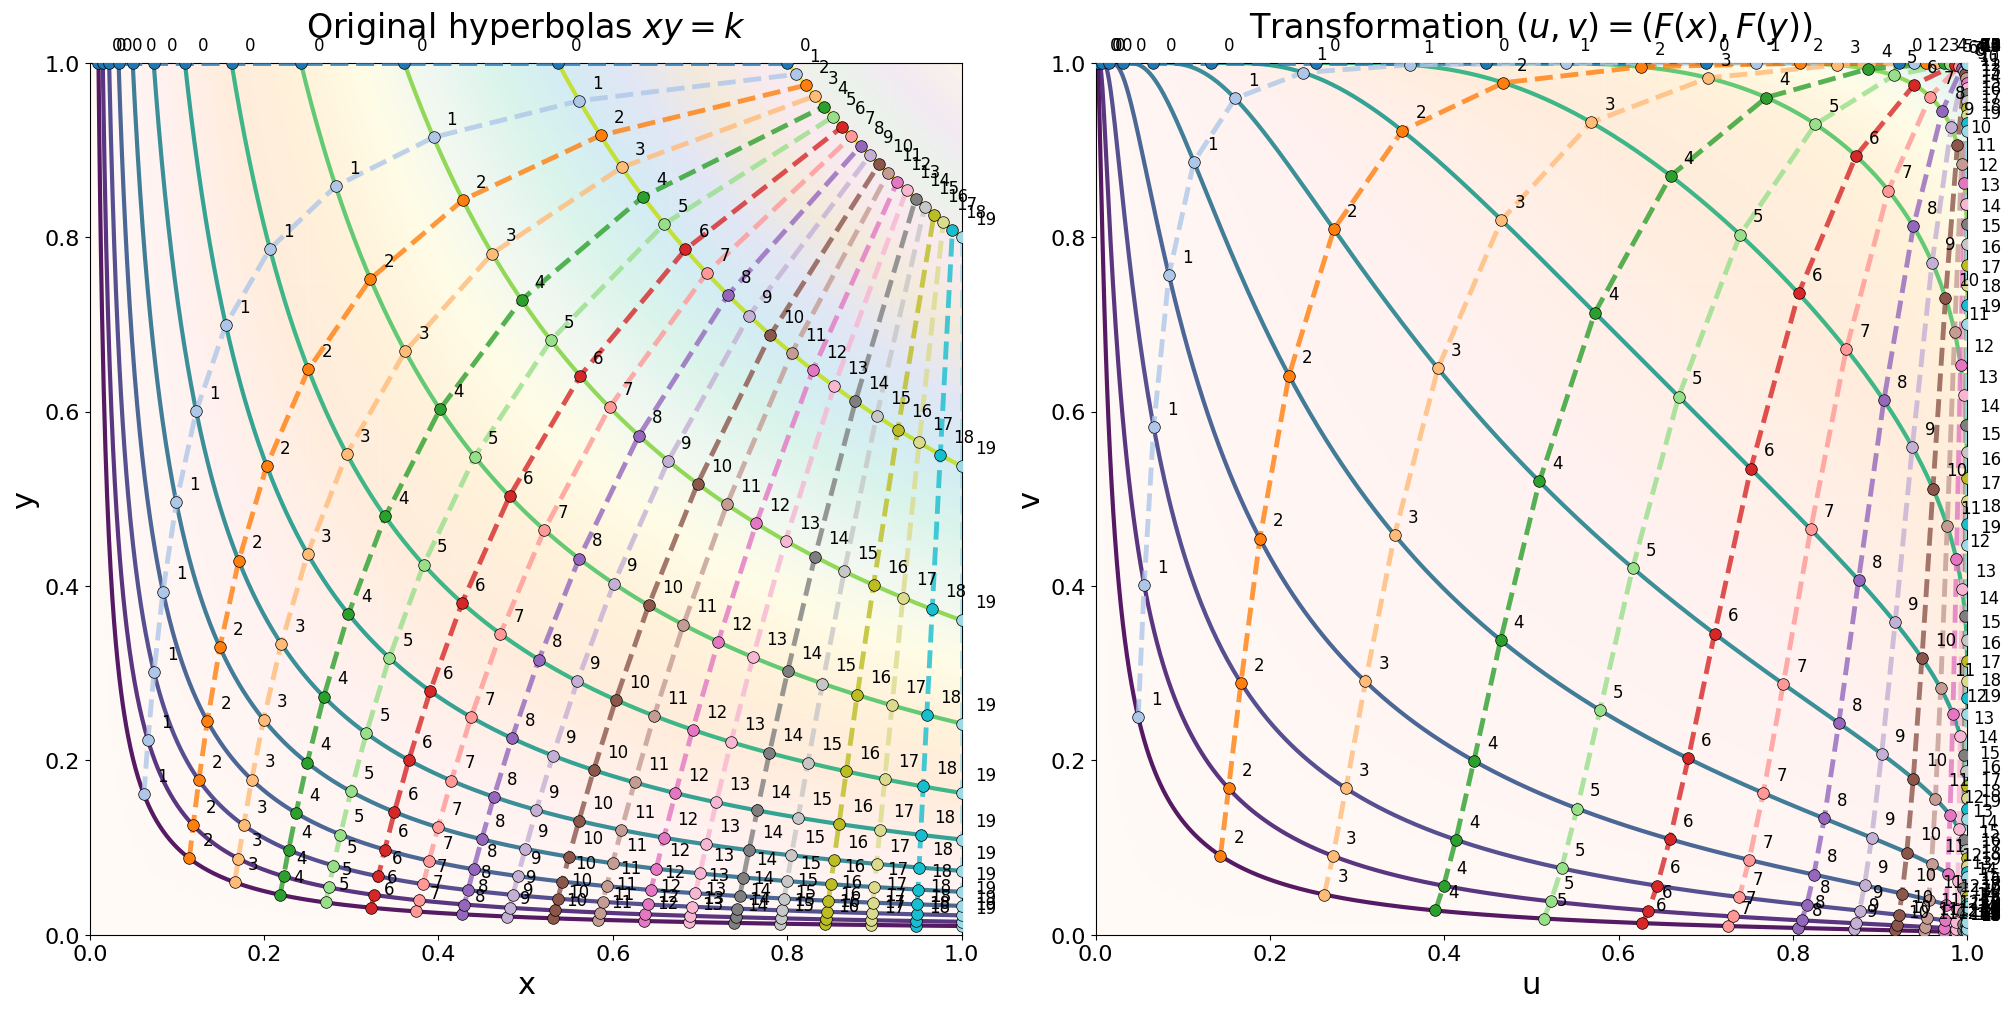

'✅ Process completed.'

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 Done! The PDF has been downloaded automatically.


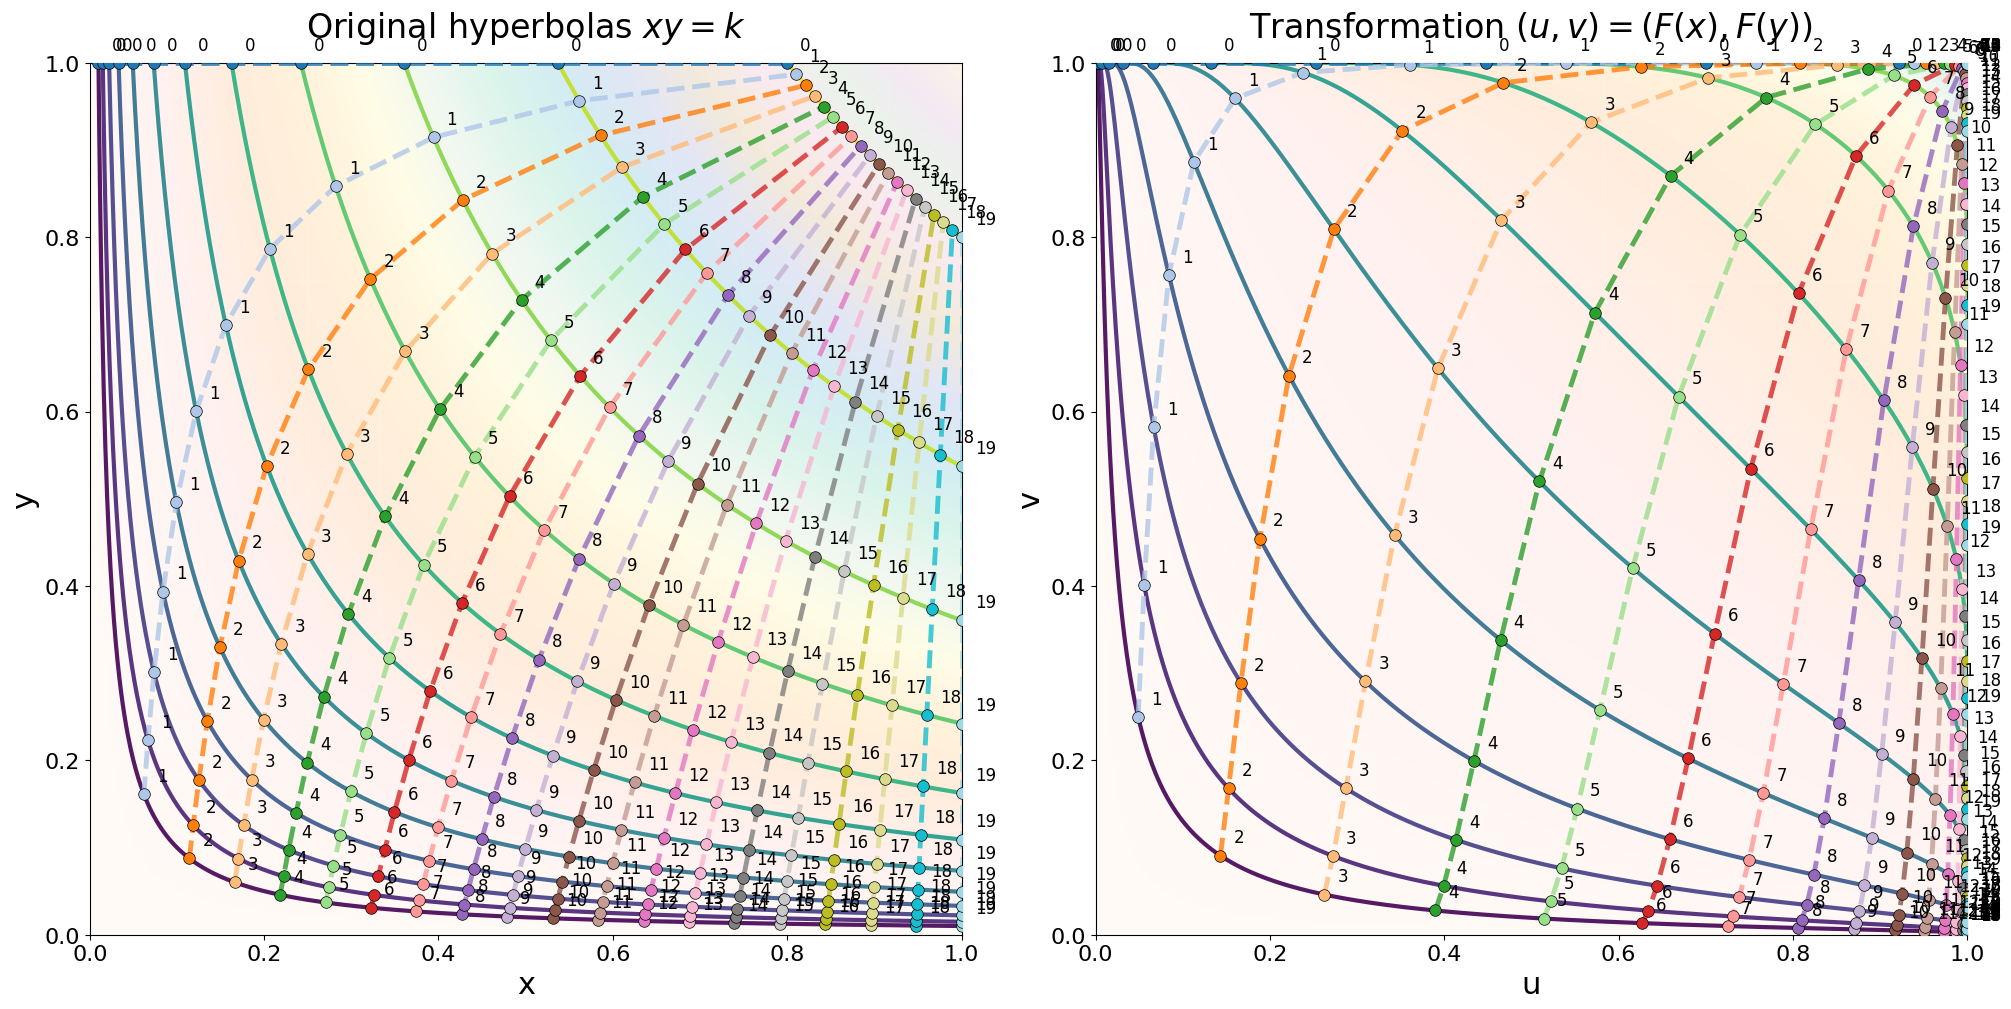

In [52]:
# ==========================================================
# INSTALL PACKAGES (automatic, run once)
# ==========================================================
!pip install -q numpy scipy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display
import time
import math

# ==========================================================
# PARAMETERS
# ==========================================================
k_values = np.geomspace(0.01, 0.8, 12)
a, b = 2, 5
num_points_per_curve = 20
line_colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
point_index_colors = plt.cm.tab20(np.linspace(0, 1, num_points_per_curve))

# ==========================================================
# SHADING (resolution reduced for speed)
# ==========================================================
def create_precise_shading(ax, is_transformed=False, alpha=0.6):
    resolution = 150
    if is_transformed:
        u_grid = np.linspace(0.001, 0.999, resolution)
        v_grid = np.linspace(0.001, 0.999, resolution)
        U, V = np.meshgrid(u_grid, v_grid)
        X = beta.ppf(U, a, b)
        Y = beta.ppf(V, a, b)
        K = X * Y
    else:
        x_grid = np.linspace(0.001, 0.999, resolution)
        y_grid = np.linspace(0.001, 0.999, resolution)
        X, Y = np.meshgrid(x_grid, y_grid)
        K = X * Y

    pastel_colors = [
        '#FFF5EE', '#FFE4E1', '#FFDAB9', '#FFE4B5', '#FFFACD',
        '#E0F0E3', '#B5EAD7', '#A8D8EA', '#C7CEEA', '#E8D5B7',
        '#F5D5E0', '#D5E8D5', '#E8D5E8', '#F5E6D5'
    ]
    pastel_cmap = LinearSegmentedColormap.from_list('pastel_gradient', pastel_colors, N=256)
    im = ax.imshow(K, extent=[0,1,0,1], origin='lower', cmap=pastel_cmap,
                   aspect='auto', vmin=0.001, vmax=1.0, zorder=0,
                   alpha=alpha, interpolation='bilinear')
    return im

# ==========================================================
# PROGRESSIVE PAUSE (starts fast, becomes ultra-fast)
# ==========================================================
def progressive_pause(i, total, initial=0.00001, final=0.0000001, factor=25):
    if total <= 1:
        return final
    fraction = i / (total - 1)
    pause = initial * math.exp(-fraction * factor) + final * (1 - math.exp(-fraction * factor))
    return max(final, pause)

# ==========================================================
# CREATE FIGURE AND SHADING
# ==========================================================
fig, ax = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
im1 = create_precise_shading(ax[0], is_transformed=False, alpha=0.5)
im2 = create_precise_shading(ax[1], is_transformed=True, alpha=0.5)

# Display the empty figure (no flicker thanks to display_id)
fig_display = display(fig, display_id=True)
status_display = display("⏳ Initializing...", display_id=True)

# ==========================================================
# STORAGE FOR MESH AND POINTS
# ==========================================================
mesh_x = [[] for _ in range(num_points_per_curve)]
mesh_y = [[] for _ in range(num_points_per_curve)]
mesh_u = [[] for _ in range(num_points_per_curve)]
mesh_v = [[] for _ in range(num_points_per_curve)]
all_x, all_y, all_u, all_v = [], [], [], []

# ==========================================================
# MAIN LOOP: DRAW HYPERBOLAS (only lines, fast)
# ==========================================================
status_display.update("🖌️ Drawing hyperbolas...")
for i, k in enumerate(k_values):
    x = np.linspace(k, 1.0, num_points_per_curve)
    y = k / x
    u = beta.cdf(x, a, b)
    v = beta.cdf(y, a, b)

    for j in range(num_points_per_curve):
        mesh_x[j].append(x[j])
        mesh_y[j].append(y[j])
        mesh_u[j].append(u[j])
        mesh_v[j].append(v[j])
    all_x.append(x); all_y.append(y); all_u.append(u); all_v.append(v)

    xx = np.linspace(k, 1.0, 1000)
    yy = k / xx
    uu = beta.cdf(xx, a, b)
    vv = beta.cdf(yy, a, b)

    ax[0].plot(xx, yy, color=line_colors[i], lw=3, alpha=0.9, zorder=2)
    ax[1].plot(uu, vv, color=line_colors[i], lw=3, alpha=0.9, zorder=2)

    # Update figure and status in-place (no flicker)
    fig_display.update(fig)
    status_display.update(f"🖌️ Hyperbola {i+1}/{len(k_values)} (k={k:.4f})")
    time.sleep(progressive_pause(i, len(k_values), 0.00001, 0.0000001, 25))

# ==========================================================
# DRAW SCATTER AND LABELS (all at once)
# ==========================================================
status_display.update("🔵 Drawing points and labels...")
for i in range(len(k_values)):
    x, y, u, v = all_x[i], all_y[i], all_u[i], all_v[i]
    for j in range(num_points_per_curve):
        ax[0].scatter(x[j], y[j], color=point_index_colors[j],
                      s=70, edgecolors='black', linewidth=0.5, zorder=5)
        ax[0].text(x[j]+0.015, y[j]+0.015, str(j), fontsize=12, zorder=6)
        ax[1].scatter(u[j], v[j], color=point_index_colors[j],
                      s=70, edgecolors='black', linewidth=0.5, zorder=5)
        ax[1].text(u[j]+0.015, v[j]+0.015, str(j), fontsize=12, zorder=6)

fig_display.update(fig)
time.sleep(0.02)

# ==========================================================
# DRAW MESH (dashed lines, update every 4 lines)
# ==========================================================
status_display.update("📐 Drawing mesh...")
total_mesh = num_points_per_curve
for j in range(total_mesh):
    color_j = point_index_colors[j]
    ax[0].plot(mesh_x[j], mesh_y[j], '--', color=color_j, lw=3.5, alpha=0.8, zorder=3)
    ax[1].plot(mesh_u[j], mesh_v[j], '--', color=color_j, lw=3.5, alpha=0.8, zorder=3)
    if (j+1) % 4 == 0 or j == total_mesh - 1:
        fig_display.update(fig)
        status_display.update(f"📐 Mesh {j+1}/{total_mesh} completed")
        time.sleep(0.001)

# ==========================================================
# FINAL FORMATTING (grid, titles)
# ==========================================================
status_display.update("🎨 Applying final formatting...")
for i in range(13):
    pos = i/12
    ax[0].axvline(x=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)
    ax[0].axhline(y=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)
    ax[1].axvline(x=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)
    ax[1].axhline(y=pos, color='white', linewidth=0.3, alpha=0.3, zorder=1)

ax[0].set_title(r'Original hyperbolas $xy=k$', fontsize=24, y=1.02)
ax[0].set_xlabel('x', fontsize=22)
ax[0].set_ylabel('y', fontsize=22)
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].set_aspect('equal')
ax[0].grid(False)

ax[1].set_title(r'Transformation $(u,v)=(F(x),F(y))$', fontsize=24, y=1.02)
ax[1].set_xlabel('u', fontsize=22)
ax[1].set_ylabel('v', fontsize=22)
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)
ax[1].set_aspect('equal')
ax[1].grid(False)

fig_display.update(fig)
status_display.update("✅ Process completed.")

# ==========================================================
# SAVE AND DOWNLOAD PDF
# ==========================================================
from google.colab import files
plt.savefig("Initial-Copula.pdf", format='pdf', dpi=300, bbox_inches='tight')
files.download("Initial-Copula.pdf")
print("🎉 Done! The PDF has been downloaded automatically.")